<a href="https://colab.research.google.com/github/qkrehdwo1144/Emergency_Patient_Priority_System/blob/main/Emergency_Patient_Priority_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

정렬 전


,환자,의식,호흡,순환,응급도
0,A,0,0,0,0
1,B,1,0,1,2
2,C,0,1,0,1
3,D,2,2,2,6
4,E,1,1,1,3
5,F,0,0,1,1
6,G,2,1,2,5
7,H,0,2,0,2
8,I,1,0,0,1
9,J,0,1,2,3


Quick Sort 수행 결과


,환자,의식,호흡,순환,응급도
0,D,2,2,2,6
1,G,2,1,2,5
2,E,1,1,1,3
3,J,0,1,2,3
4,B,1,0,1,2
5,H,0,2,0,2
6,C,0,1,0,1
7,F,0,0,1,1
8,I,1,0,0,1
9,A,0,0,0,0


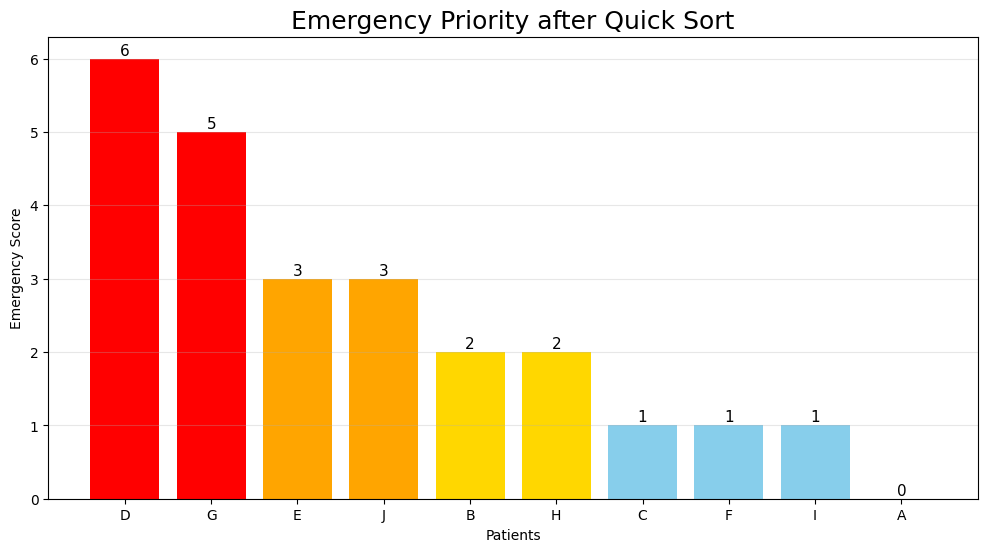

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

patients = [
    ["A",0,0,0],
    ["B",1,0,1],
    ["C",0,1,0],
    ["D",2,2,2],
    ["E",1,1,1],
    ["F",0,0,1],
    ["G",2,1,2],
    ["H",0,2,0],
    ["I",1,0,0],
    ["J",0,1,2]
]

df = pd.DataFrame(
    patients,
    columns=["환자","의식","호흡","순환"]
)

df["응급도"] = df["의식"]+df["호흡"]+df["순환"]

def quick_sort(arr):

    if len(arr)<=1:
        return arr

    pivot=arr[len(arr)//2]["응급도"]

    left=[x for x in arr if x["응급도"]>pivot]
    middle=[x for x in arr if x["응급도"]==pivot]
    right=[x for x in arr if x["응급도"]<pivot]

    return quick_sort(left)+middle+quick_sort(right)

sorted_list=quick_sort(df.to_dict("records"))

sorted_df=pd.DataFrame(sorted_list)

print("="*50)
print("정렬 전")
print("="*50)
display(df)

print("="*50)
print("Quick Sort 수행 결과")
print("="*50)
display(sorted_df)

plt.figure(figsize=(12,6))

colors=[]

for score in sorted_df["응급도"]:

    if score>=5:
        colors.append("red")
    elif score>=3:
        colors.append("orange")
    elif score>=2:
        colors.append("gold")
    else:
        colors.append("skyblue")

plt.bar(sorted_df["환자"],sorted_df["응급도"],color=colors)

plt.title("Emergency Priority after Quick Sort",fontsize=18)
plt.xlabel("Patients")
plt.ylabel("Emergency Score")

for i,v in enumerate(sorted_df["응급도"]):
    plt.text(i,v+0.05,str(v),ha='center',fontsize=11)

plt.grid(axis='y',alpha=0.3)

plt.show()